# Notebook 03 — Transfer Learning Binario
## Clasificación de Lesiones Cutáneas Pigmentadas (HAM10000)
**Iteración 2:** Transfer learning con VGG16, ResNet50 y EfficientNet-B0  
Tarea: Clasificación binaria (Maligno vs. Benigno)

---
### Objetivo
Comparar tres arquitecturas preentrenadas en ImageNet con fine-tuning sobre HAM10000.  
Todas las variantes incluyen **pesos de clase** en la función de pérdida para mitigar el desbalance.  
Se evalúan en **test set** con métricas completas para seleccionar el mejor modelo para la Iteración 3.

### Estructura
1. Ingesta y DataLoaders (idéntico split al NB01/NB02)
2. Configuración de los tres modelos (congelado de backbone + cabeza nueva)
3. Entrenamiento comparativo (5 épocas × 3 modelos)
4. Evaluación completa en test set: balanced accuracy, F1-macro, AUC-ROC
5. Tabla comparativa y selección del mejor modelo


In [5]:
# ============================================================
# CELDA 1: INSTALACIONES Y CONFIGURACIÓN
# ============================================================
!pip install -q kaggle scikit-learn matplotlib seaborn pandas Pillow torch torchvision tqdm
import os, json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
import torchvision.models as models
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, classification_report,
                              balanced_accuracy_score, roc_auc_score,
                              f1_score, roc_curve, auc)
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print(f"Dispositivo: {device}")


Dispositivo: cpu


In [1]:
# ============================================================
# CELDA 2: INGESTA DE DATOS — KAGGLE SECRETS O GOOGLE DRIVE
# ============================================================
import os, json, zipfile
import glob as glob_module

UNZIP_DIR       = '/content/dataset/unzipped'
DRIVE_FOLDER_ID = '1CCdAHVv0K3whsHxedqVqgqzs2aesWIYR'

if not os.path.exists(UNZIP_DIR) or len(os.listdir(UNZIP_DIR)) == 0:
    os.makedirs(UNZIP_DIR, exist_ok=True)

    # ── Intento 1: Kaggle Secrets ──────────────────────────────
    kaggle_ok = False
    try:
        from google.colab import userdata
        KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
        KAGGLE_KEY      = userdata.get('KAGGLE_KEY')
        os.makedirs('/root/.kaggle', exist_ok=True)
        with open('/root/.kaggle/kaggle.json', 'w') as f:
            json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
        !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/dataset -q
        with zipfile.ZipFile('/content/dataset/skin-cancer-mnist-ham10000.zip', 'r') as zf:
            zf.extractall(UNZIP_DIR)
        kaggle_ok = True
        print("✅ Dataset cargado desde Kaggle")
    except Exception:
        print("⚠️  Kaggle Secrets no disponibles → usando Google Drive...")

    # ── Intento 2: Google Drive (fallback) ────────────────────
    if not kaggle_ok:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        DRIVE_PATH = '/content/drive/MyDrive/HAM10000_dataset'
        if os.path.exists(DRIVE_PATH):
            print("Copiando desde Google Drive (puede tardar unos minutos)...")
            !cp -r "{DRIVE_PATH}"/* "{UNZIP_DIR}/"
            print("✅ Dataset cargado desde Google Drive")
        else:
            !pip install -q gdown
            import gdown
            gdown.download_folder(
                f'https://drive.google.com/drive/folders/{DRIVE_FOLDER_ID}',
                output=UNZIP_DIR, quiet=False, use_cookies=False)
            print("✅ Dataset descargado desde Google Drive (enlace público)")
else:
    print("✅ Dataset ya disponible en", UNZIP_DIR)

# ── Buscar CSV automáticamente ────────────────────────────────
csvs    = glob_module.glob('/content/**/*metadata*.csv', recursive=True)
CSV_PATH  = csvs[0] if csvs else f'{UNZIP_DIR}/HAM10000_metadata.csv'
IMAGE_DIR = UNZIP_DIR
print(f"CSV encontrado: {CSV_PATH}")


⚠️  Kaggle Secrets no disponibles → usando Google Drive...
Mounted at /content/drive
Copiando desde Google Drive (puede tardar unos minutos)...
✅ Dataset cargado desde Google Drive
CSV encontrado: /content/dataset/unzipped/HAM10000_images_part_1/HAM10000_metadata.csv


In [6]:

# ============================================================
# CELDA 3: DATASET BINARIO Y SPLIT POR LESION_ID
# ============================================================
MALIGNOS = ['mel', 'bcc', 'akiec']

class HAM10000_Binario(Dataset):
    """Dataset binario — imágenes RGB 3 canales, redimensionadas a 224x224."""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img   = Image.open(self.df['path'].iloc[idx]).convert('RGB')
        label = 1 if self.df['dx'].iloc[idx] in MALIGNOS else 0
        if self.transform: img = self.transform(img)
        return img, label

df_meta = pd.read_csv(CSV_PATH)
todas   = glob(os.path.join(UNZIP_DIR,'**','*.jpg'), recursive=True)
df_meta['path'] = df_meta['image_id'].map(
    {os.path.splitext(os.path.basename(x))[0]: x for x in todas})
df_meta = df_meta.dropna(subset=['path'])

groups   = df_meta['lesion_id'].values
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
idx_tv, idx_test = next(gss_test.split(np.arange(len(df_meta)), groups=groups))
gss_val  = GroupShuffleSplit(n_splits=1, test_size=0.111, random_state=SEED)
idx_tr_r, idx_val_r = next(gss_val.split(idx_tv, groups=groups[idx_tv]))
df_train = df_meta.iloc[idx_tv[idx_tr_r]]
df_val   = df_meta.iloc[idx_tv[idx_val_r]]
df_test  = df_meta.iloc[idx_test]
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

BATCH = 32
train_loader = DataLoader(HAM10000_Binario(df_train, transform_train),
                          batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(HAM10000_Binario(df_val,   transform_val),
                          batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(HAM10000_Binario(df_test,  transform_val),
                          batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# Pesos de clase
y_bin = df_train['dx'].apply(lambda x: 1 if x in MALIGNOS else 0).values
pesos = compute_class_weight('balanced', classes=np.array([0,1]), y=y_bin)
pesos_tensor = torch.tensor(pesos, dtype=torch.float).to(device)
print(f"Pesos → Benigno: {pesos[0]:.3f} | Maligno: {pesos[1]:.3f}")

Train: 3988 | Val: 497 | Test: 515
Pesos → Benigno: 0.608 | Maligno: 2.816


### Celda 4 — Configuración de modelos preentrenados
Estrategia: **Feature extraction** — se congela el backbone preentrenado en ImageNet  
y se reemplaza únicamente la capa de clasificación final por una de 2 neuronas.  
Solo los parámetros de la nueva capa son entrenables en esta fase.


In [ ]:
# ============================================================
# CELDA 4: CONFIGURACIÓN DE LOS TRES MODELOS
# ============================================================
def construir_modelo(nombre):
    """
    Carga modelo preentrenado (ImageNet), congela backbone,
    reemplaza clasificador final por salida de 2 clases.
    """
    if nombre == 'vgg16':
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        for p in m.features.parameters(): p.requires_grad = False
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, 2)
        params_train = list(m.classifier.parameters())

    elif nombre == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        for p in m.parameters(): p.requires_grad = False
        m.fc = nn.Linear(m.fc.in_features, 2)
        params_train = list(m.fc.parameters())

    elif nombre == 'efficientnet_b0':
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        for p in m.features.parameters(): p.requires_grad = False
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, 2)
        params_train = list(m.classifier.parameters())

    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    print(f"{nombre:15s} | Params entrenables: {trainable:,} / {total:,} "
          f"({trainable/total*100:.1f}%)")
    return m.to(device), params_train

print("Cargando modelos preentrenados (ImageNet)...")
modelo_vgg,       params_vgg       = construir_modelo('vgg16')
modelo_resnet,    params_resnet    = construir_modelo('resnet50')
modelo_efficient, params_efficient = construir_modelo('efficientnet_b0')


Cargando modelos preentrenados (ImageNet)...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 136MB/s]


vgg16           | Params entrenables: 119,554,050 / 134,268,738 (89.0%)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


resnet50        | Params entrenables: 4,098 / 23,512,130 (0.0%)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 162MB/s]

efficientnet_b0 | Params entrenables: 2,562 / 4,010,110 (0.1%)


In [ ]:
# ============================================================
# CELDA 5: FUNCIÓN DE ENTRENAMIENTO CON PESOS DE CLASE
# ============================================================
def entrenar_tl(modelo, params_train, nombre, epochs=5, lr=0.001):
    criterio    = nn.CrossEntropyLoss(weight=pesos_tensor)
    optimizador = optim.Adam(params_train, lr=lr)
    hist        = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc']}

    print(f"\n{'='*45}")
    print(f"  {nombre.upper()} — {epochs} épocas con pesos de clase")
    print(f"{'='*45}")

    for epoch in range(epochs):
        modelo.train()
        tl, tc, tt = 0., 0, 0
        for X, y in tqdm(train_loader, desc=f'Época {epoch+1}/{epochs}', leave=False):
            X, y = X.to(device), y.to(device)
            optimizador.zero_grad()
            out  = modelo(X); loss = criterio(out, y)
            loss.backward(); optimizador.step()
            tl += loss.item()*X.size(0); tc += (out.argmax(1)==y).sum().item(); tt += y.size(0)

        modelo.eval(); vl, vc, vt = 0., 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out  = modelo(X); loss = criterio(out, y)
                vl += loss.item()*X.size(0); vc += (out.argmax(1)==y).sum().item(); vt += y.size(0)

        hist['train_loss'].append(tl/tt); hist['val_loss'].append(vl/vt)
        hist['train_acc'].append(tc/tt);  hist['val_acc'].append(vc/vt)
        print(f"  Época {epoch+1} | Train Acc: {tc/tt:.4f} | Val Loss: {vl/vt:.4f} | Val Acc: {vc/vt:.4f}")

    return hist

EPOCHS = 5
print("▶ Entrenando los 3 modelos secuencialmente (paciencia ≈ 15 min con GPU)...")
hist_vgg       = entrenar_tl(modelo_vgg,       params_vgg,       'VGG16',          EPOCHS)
hist_resnet    = entrenar_tl(modelo_resnet,    params_resnet,    'ResNet50',        EPOCHS)
hist_efficient = entrenar_tl(modelo_efficient, params_efficient, 'EfficientNet-B0', EPOCHS)
print("\n✅ Entrenamiento de los 3 modelos completado")


▶ Entrenando los 3 modelos secuencialmente (paciencia ≈ 15 min con GPU)...

  VGG16 — 5 épocas con pesos de clase


  Época 1 | Train Acc: 0.6757 | Val Loss: 0.7527 | Val Acc: 0.8060


  Época 2 | Train Acc: 0.6631 | Val Loss: 0.6703 | Val Acc: 0.6945


  Época 3 | Train Acc: 0.6706 | Val Loss: 0.6850 | Val Acc: 0.7403


  Época 4 | Train Acc: 0.6961 | Val Loss: 0.8841 | Val Acc: 0.5294


...

  Época 1 | Train Acc: 0.7355 | Val Loss: 0.4759 | Val Acc: 0.7861


  Época 2 | Train Acc: 0.7675 | Val Loss: 0.4366 | Val Acc: 0.7940


  Época 3 | Train Acc: 0.7639 | Val Loss: 0.4245 | Val Acc: 0.8060


  Época 4 | Train Acc: 0.7728 | Val Loss: 0.4257 | Val Acc: 0.8030


  Época 5 | Train Acc: 0.7704 | Val Loss: 0.5158 | Val Acc: 0.8000

✅ Entrenamiento de los 3 modelos completado


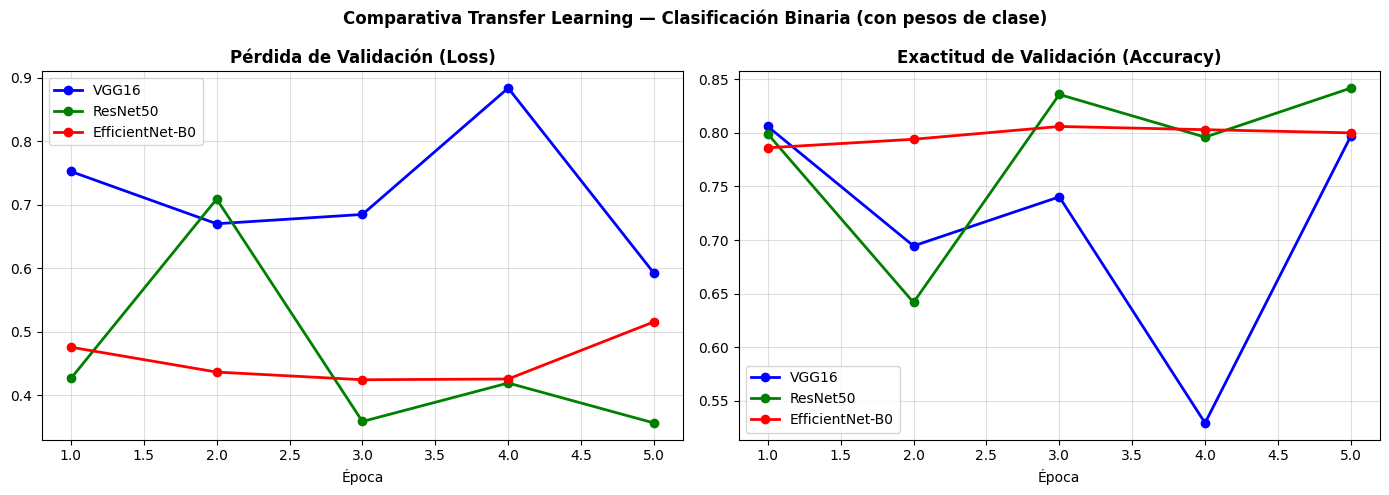


--- RESUMEN ÚLTIMA ÉPOCA (VALIDACIÓN) ---
  VGG16              → Val Loss: 0.5924 | Val Acc: 0.7970
  ResNet50           → Val Loss: 0.3564 | Val Acc: 0.8418
  EfficientNet-B0    → Val Loss: 0.5158 | Val Acc: 0.8000


In [ ]:
# ============================================================
# CELDA 6: CURVAS DE APRENDIZAJE COMPARATIVAS
# ============================================================
epocas = range(1, EPOCHS+1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

config = [
    ('vgg16',          hist_vgg,       'blue',  'VGG16'),
    ('resnet50',       hist_resnet,    'green', 'ResNet50'),
    ('efficientnet_b0',hist_efficient, 'red',   'EfficientNet-B0'),
]

for metrica, titulo, ax in [
    (('train_loss','val_loss'), 'Pérdida de Validación (Loss)', axes[0]),
    (('train_acc', 'val_acc'),  'Exactitud de Validación (Accuracy)', axes[1])
]:
    for _, hist, color, label in config:
        ax.plot(epocas, hist[metrica[1]], color=color, marker='o', label=label, linewidth=2)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Época'); ax.legend(); ax.grid(True, alpha=0.4)

plt.suptitle('Comparativa Transfer Learning — Clasificación Binaria (con pesos de clase)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig_tl_curvas_comparativas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- RESUMEN ÚLTIMA ÉPOCA (VALIDACIÓN) ---")
for _, hist, _, nombre in config:
    print(f"  {nombre:18s} → Val Loss: {hist['val_loss'][-1]:.4f} | Val Acc: {hist['val_acc'][-1]:.4f}")


In [ ]:
# ============================================================
# CELDA 7: EVALUACIÓN COMPLETA EN TEST SET
# ============================================================
def evaluar_completo(modelo, loader, nombre):
    modelo.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for X, y in loader:
            X   = X.to(device)
            out = modelo(X)
            p   = torch.softmax(out, dim=1)[:, 1]
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())
            probs.extend(p.cpu().numpy())

    preds, labels, probs = map(np.array, [preds, labels, probs])
    bal   = balanced_accuracy_score(labels, preds)
    f1m   = f1_score(labels, preds, average='macro')
    auroc = roc_auc_score(labels, probs)
    acc   = (preds == labels).mean()

    print(f"\n{'='*50}")
    print(f"  TEST SET — {nombre}")
    print(f"{'='*50}")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Balanced Accuracy : {bal:.4f}  ← métrica principal")
    print(f"  F1-Score Macro    : {f1m:.4f}")
    print(f"  AUC-ROC           : {auroc:.4f}")
    print()
    print(classification_report(labels, preds, target_names=['Benigno','Maligno']))
    return dict(preds=preds, labels=labels, probs=probs,
                acc=acc, bal=bal, f1=f1m, auc=auroc, nombre=nombre)

print("Evaluando los 3 modelos en TEST SET...")
res_vgg       = evaluar_completo(modelo_vgg,       test_loader, 'VGG16')
res_resnet    = evaluar_completo(modelo_resnet,    test_loader, 'ResNet50')
res_efficient = evaluar_completo(modelo_efficient, test_loader, 'EfficientNet-B0')


Evaluando los 3 modelos en TEST SET...

  TEST SET — VGG16
  Accuracy          : 0.7456
  Balanced Accuracy : 0.7344  ← métrica principal
  F1-Score Macro    : 0.6770
  AUC-ROC           : 0.8071

              precision    recall  f1-score   support

     Benigno       0.91      0.75      0.83       822
     Maligno       0.42      0.72      0.53       204

    accuracy                           0.75      1026
   macro avg       0.67      0.73      0.68      1026
weighted avg       0.82      0.75      0.77      1026


  TEST SET — ResNet50
  Accuracy          : 0.8099
  Balanced Accuracy : 0.7450  ← métrica principal
  F1-Score Macro    : 0.7247
  AUC-ROC           : 0.8503

              precision    recall  f1-score   support

     Benigno       0.90      0.85      0.88       822
     Maligno       0.52      0.64      0.57       204

    accuracy                           0.81      1026
   macro avg       0.71      0.75      0.72      1026
weighted avg       0.83      0.81      0.82

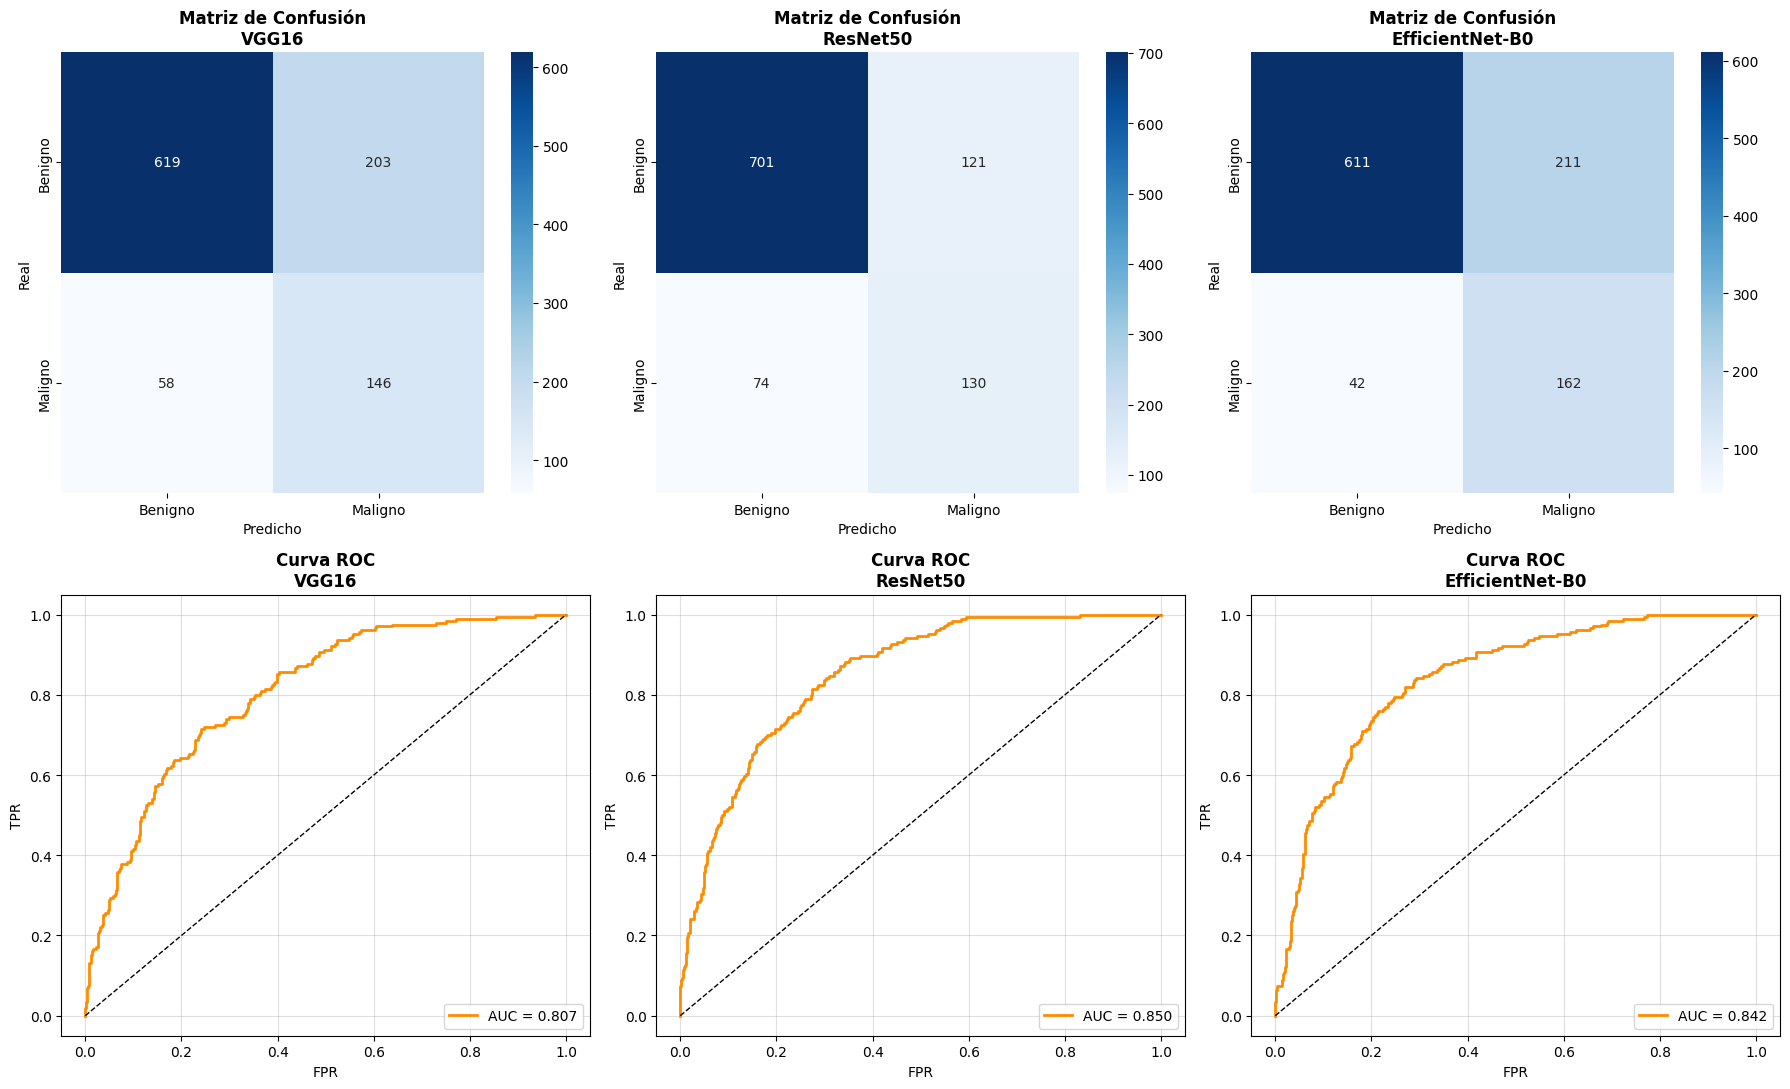


--- TABLA COMPARATIVA FINAL (TEST SET) ---
         Modelo  Accuracy  Balanced Acc  F1 Macro  AUC-ROC
          VGG16    0.7456        0.7344    0.6770   0.8071
       ResNet50    0.8099        0.7450    0.7247   0.8503
EfficientNet-B0    0.7534        0.7687    0.6950   0.8418

🏆 MEJOR MODELO (por Balanced Accuracy): EfficientNet-B0
   → Será usado en el Notebook 04 para clasificación multiclase


In [ ]:
# ============================================================
# CELDA 8: MATRICES DE CONFUSIÓN Y CURVAS ROC
# ============================================================
resultados = [res_vgg, res_resnet, res_efficient]
fig, axes  = plt.subplots(2, 3, figsize=(18, 11))

for col, res in enumerate(resultados):
    # Matriz de confusión
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, col],
                xticklabels=['Benigno','Maligno'],
                yticklabels=['Benigno','Maligno'])
    axes[0, col].set_title(f"Matriz de Confusión\n{res['nombre']}", fontweight='bold')
    axes[0, col].set_ylabel('Real'); axes[0, col].set_xlabel('Predicho')

    # Curva ROC
    fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
    axes[1, col].plot(fpr, tpr, lw=2, color='darkorange',
                      label=f"AUC = {auc(fpr,tpr):.3f}")
    axes[1, col].plot([0,1],[0,1],'k--', lw=1)
    axes[1, col].set_title(f"Curva ROC\n{res['nombre']}", fontweight='bold')
    axes[1, col].set_xlabel('FPR'); axes[1, col].set_ylabel('TPR')
    axes[1, col].legend(loc='lower right'); axes[1, col].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('/content/fig_tl_evaluacion_test.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabla comparativa final ──
print("\n--- TABLA COMPARATIVA FINAL (TEST SET) ---")
df_comp = pd.DataFrame([
    {'Modelo': r['nombre'], 'Accuracy': round(r['acc'],4),
     'Balanced Acc': round(r['bal'],4), 'F1 Macro': round(r['f1'],4),
     'AUC-ROC': round(r['auc'],4)}
    for r in resultados
])
print(df_comp.to_string(index=False))

# ── Selección del mejor modelo ──
mejor = max(resultados, key=lambda r: r['bal'])
print(f"\n🏆 MEJOR MODELO (por Balanced Accuracy): {mejor['nombre']}")
print(f"   → Será usado en el Notebook 04 para clasificación multiclase")
